### How do Transformers learn from sequences? How do they generate tokens?

Designed by: [Tirtharaj Dash](https://tirtharajdash.github.io), *Assistance from: Claude*

We use `numpy` for hand-worked numericals and `torch` only when we are ready to train a tiny model. 
We will not download anything else.

In [49]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

NumPy: 2.1.2
PyTorch: 2.8.0+cu129


#### Part I: Fundamentals of Neural Networks

A model is a function with adjustable numbers. A simple model might compute

$$
y=w_1x_1+w_2x_2+b.
$$

A model is defined by a pair $(\pi: \text{ structure},\theta: \text{ parameters})$. The numbers $w_1,w_2,b$ are **parameters** of a model. What is the **structure** of the model here? Training means changing parameters so that predictions improve.

A neural network is a larger composition of parameterised computations. For this lecture, that idea is enough.

In [52]:
## A tiny model: y = w1*x1 + w2*x2 + b

x = np.array([2.0, 3.0])
w = np.array([0.5, -1.0])   # parameters
b = 0.2                     # parameter

y = x @ w + b               # matrix multiplication + additive bias

print("input x      =", x)
print("parameters w =", w)
print("bias b       =", b)
print("model output =", y)

input x      = [2. 3.]
parameters w = [ 0.5 -1. ]
bias b       = 0.2
model output = -1.8


**A linear layer does many weighted sums at once**. For a vector $x$, a linear layer computes

$$
y=xW+b.
$$

*This operation appears throughout a Transformer*: in Q/K/V projections, output projections, feed-forward networks, and vocabulary prediction.

In [53]:
## Map a 3-dimensional input to a 2-dimensional output.

x = np.array([1.0, 2.0, -1.0])
W = np.array([
    [ 1.0,  0.0],
    [ 0.5, -1.0],
    [-1.0,  2.0],
])
b = np.array([0.1, 0.2])

y = x @ W + b

print("x shape:", x.shape)
print("W shape:", W.shape)
print("y shape:", y.shape)
print("y =", y)

x shape: (3,)
W shape: (3, 2)
y shape: (2,)
y = [ 3.1 -3.8]


**Logits are scores, not probabilities**; we compute probabilities using those logits. 

A language model eventually produces one score for every possible next token. These scores are called **logits**.

Softmax converts logits $z_i$ to probabilities:

$$
p_i=\frac{e^{z_i}}{\sum_j e^{z_j}}.
$$

Q: Compute by hand the softmax of $[2,1,0]$ approximately (of course, you need a calculator), then run the cell.

In [54]:
def softmax_numpy(logits):
    """Numerically stable softmax."""
    logits = np.asarray(logits, dtype=float)
    shifted = logits - logits.max()
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()

logits = np.array([2.0, 1.0, 0.0])
probs = softmax_numpy(logits)

print("logits        =", logits)
print("probabilities =", np.round(probs, 4))
print("sum           =", probs.sum())

logits        = [2. 1. 0.]
probabilities = [0.6652 0.2447 0.09  ]
sum           = 0.9999999999999999


**Cross-entropy loss: how unhappy is the model?**

If the correct next token receives probability $p$, the one-example loss is

$$
L=-\log p.
$$

(Recall that our target/ground-truth is usually a one-hot encoded token ID: $[0,\dots,1,\dots,0]$. So the loss above is actually, taking that $1$ and multiplying with the log-likelihood of predicting that token ID: $\log P$.)

So high probability for the correct answer gives small loss; low probability gives large loss.

In [55]:
for p_correct in [0.9, 0.5, 0.1, 0.01]:
    loss = -np.log(p_correct)
    print(f"p(correct)={p_correct:>4} -> loss={loss:.4f}")

p(correct)= 0.9 -> loss=0.1054
p(correct)= 0.5 -> loss=0.6931
p(correct)= 0.1 -> loss=2.3026
p(correct)=0.01 -> loss=4.6052


**What does learning mean?**

Suppose $\hat y=wx$, with input $x=2$ and desired target $y=6$. Training should discover $w\approx3$.

PyTorch computes how the loss changes with the parameter and lets us update it.

In [56]:
x = torch.tensor(2.0)
target = torch.tensor(6.0)

## Start from a deliberately bad parameter.
w = torch.tensor(0.0, requires_grad=True)
learning_rate = 0.1

for step in range(8):
    prediction = w * x
    loss = (prediction - target) ** 2

    # Compute derivative of loss with respect to w.
    loss.backward()

    # Change w in the direction that lowers the loss.
    with torch.no_grad():
        w -= learning_rate * w.grad

    # Gradients accumulate in PyTorch, so clear the old one.
    w.grad.zero_()

    print(f"step={step:2d}  w={w.item():.4f}  loss={loss.item():.4f}")

step= 0  w=2.4000  loss=36.0000
step= 1  w=2.8800  loss=1.4400
step= 2  w=2.9760  loss=0.0576
step= 3  w=2.9952  loss=0.0023
step= 4  w=2.9990  loss=0.0001
step= 5  w=2.9998  loss=0.0000
step= 6  w=3.0000  loss=0.0000
step= 7  w=3.0000  loss=0.0000


#### Part II: Language Modelling

**A generative language model predicts the next token.**

A decoder-only language model learns

$$
P(x_t\mid x_1,\ldots,x_{t-1}).
$$

For `cats chase mice`, the training questions include:

- after `cats`, what comes next?
- after `cats chase`, what comes next?

Generation repeats this next-token prediction again and again.

In [57]:
sentence = "cats chase mice"
tokens = sentence.split()

for t in range(1, len(tokens)):
    prefix = tokens[:t]
    target = tokens[t]
    print("context:", prefix, "-> target:", target)

context: ['cats'] -> target: chase
context: ['cats', 'chase'] -> target: mice


**Tokenisation: text must become integers.** Computers cannot understand anything other than numbers, in fact, Booleans only.

For today, we begin with a character-level tokenizer. Each distinct character receives an integer ID.

A real system often uses subword tokens, but the Transformer does not fundamentally require a particular tokenisation scheme.

In [58]:
text = "hello transformer"

vocab = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}

encoded = [stoi[ch] for ch in text]
decoded = "".join(itos[i] for i in encoded)

print("vocabulary:", vocab)
print("encoded   :", encoded)
print("decoded   :", decoded)

vocabulary: [' ', 'a', 'e', 'f', 'h', 'l', 'm', 'n', 'o', 'r', 's', 't']
encoded   : [4, 2, 5, 5, 8, 0, 11, 9, 1, 7, 10, 3, 8, 9, 6, 2, 9]
decoded   : hello transformer


**The simplest generative model: a bigram model**

A bigram model estimates

$$
P(x_t\mid x_{t-1}).
$$

It looks **at only one previous token**. We can build one simply by counting what follows what; Recall, our probability lookup table discussed during the class.

In [59]:
toy_text = "banana bandana"

vocab = sorted(set(toy_text))
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}
V = len(vocab)

## counts[i,j] = number of times token j follows token i
counts = np.zeros((V, V), dtype=int)
for a, b in zip(toy_text[:-1], toy_text[1:]):
    counts[stoi[a], stoi[b]] += 1

print("vocabulary:", vocab)
print("bigram counts:\n", counts)

vocabulary: [' ', 'a', 'b', 'd', 'n']
bigram counts:
 [[0 0 1 0 0]
 [1 0 0 0 4]
 [0 2 0 0 0]
 [0 1 0 0 0]
 [0 3 0 1 0]]


**Did you know: Even the bigram model can generate**

Turn each row of counts into a probability distribution, sample a next token, append it, and repeat.

This is already generative modelling — but with an *extremely short memory*.

In [60]:
probs = counts + 0.1  # tiny smoothing
probs = probs / probs.sum(axis=1, keepdims=True)

rng = np.random.default_rng(0)
current = "b"
generated = [current]

for _ in range(40):
    next_id = rng.choice(V, p=probs[stoi[current]])
    current = itos[next_id]
    generated.append(current)

print("".join(generated))

bana bbanand b banana ananannanananananda


**Why one-token context is not enough**

Compare:

- `I grew up in France. I speak fluent ...`
- `I grew up in Japan. I speak fluent ...`

The useful clue can occur many tokens earlier. We need a mechanism that lets the current token obtain information from relevant earlier tokens.

That mechanism is **self-attention**.

In [11]:
examples = [
    ("I grew up in France . I speak fluent", "French"),
    ("I grew up in Japan . I speak fluent", "Japanese"),
]

for context, likely_next in examples:
    print("full context:", context)
    print("bigram model sees only:", repr(context.split()[-1]))
    print("likely continuation:", likely_next)
    print("-" * 60)

full context: I grew up in France . I speak fluent
bigram model sees only: 'fluent'
likely continuation: French
------------------------------------------------------------
full context: I grew up in Japan . I speak fluent
bigram model sees only: 'fluent'
likely continuation: Japanese
------------------------------------------------------------


#### Part III: Embeddings

**An embedding is a learned lookup table**

If vocabulary size is $V$ and model width is $d_{\text{model}}$, the embedding table has shape

$$
V\times d_{\text{model}}.
$$

Token ID $i$ selects row $i$. The row is a learned vector.

**Token ID is not the embedding.** The ID is only an index.

In [61]:
embedding_table = np.array([
    [ 0.2,  0.1, -0.5,  0.7],
    [-0.3,  0.8,  0.4,  0.1],
    [ 0.6, -0.2,  0.0,  0.3],
    [ 0.1,  0.9, -0.4, -0.2],
    [ 0.5,  0.2,  0.2, -0.6],
])

token_ids = np.array([2, 0, 3])
X = embedding_table[token_ids]

print("token IDs:", token_ids)
print("embedding table shape:", embedding_table.shape)
print("sequence representation shape:", X.shape)
print(X)

token IDs: [2 0 3]
embedding table shape: (5, 4)
sequence representation shape: (3, 4)
[[ 0.6 -0.2  0.   0.3]
 [ 0.2  0.1 -0.5  0.7]
 [ 0.1  0.9 -0.4 -0.2]]


**A first neural next-token model:**

The simplest neural language model can be

$$
\text{token ID}\rightarrow\text{embedding}\rightarrow\text{linear layer}\rightarrow\text{vocabulary logits}.
$$

It can learn next-token preferences, but it still uses only the current token.

In [62]:
class TinyOneTokenLM(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):
        x = self.embedding(token_ids)
        logits = self.output(x)
        return logits

model = TinyOneTokenLM(vocab_size=10, d_model=6)
ids = torch.tensor([1, 4, 2])
logits = model(ids)

print("input shape :", ids.shape)
print("logit shape :", logits.shape)

input shape : torch.Size([3])
logit shape : torch.Size([3, 10])


#### Part IV: Self-attention

**What problem does attention solve?**

For each token, ask:

> Which earlier tokens contain useful information for updating my representation?

For each token representation $x$, the model creates three learned projections:

- **query** $q$: what am I looking for?
- **key** $k$: what kind of information do I contain?
- **value** $v$: what information should I contribute if selected?

These are not manually designed semantic labels. They are learned vectors.

In [63]:
x = np.array([1.0, 2.0, 0.0, -1.0])

## Let's design some projection matrices 
W_Q = np.array([[1.,0.],[0.,1.],[1.,1.],[0.,1.]])
W_K = np.array([[0.,1.],[1.,0.],[1.,0.],[0.,1.]])
W_V = np.array([[1.,1.],[1.,0.],[0.,1.],[1.,-1.]])

q = x @ W_Q
k = x @ W_K
v = x @ W_V

print("x =", x)
print("q =", q)
print("k =", k)
print("v =", v)

x = [ 1.  2.  0. -1.]
q = [1. 1.]
k = [2. 0.]
v = [2. 2.]


**Queries are compared with keys using dot products**

For token $i$ attending to token $j$, a basic relevance score is

$$
q_i^\top k_j.
$$

Large score means the learned query and key are well aligned.

In [64]:
q = np.array([1.0, 2.0])
keys = {
    "token A": np.array([1.0, 0.0]),
    "token B": np.array([0.0, 1.0]),
    "token C": np.array([1.0, 1.0]),
}

for name, k in keys.items():
    print(f"{name}: q·k = {q @ k:.1f}")

token A: q·k = 1.0
token B: q·k = 2.0
token C: q·k = 3.0


**Complete scaled dot-product attention**

For matrices $Q,K,V$,

$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

Q. With
$
Q=K=\begin{bmatrix}1&0\\0&1\\1&1\end{bmatrix},
\qquad
V=\begin{bmatrix}10&0\\0&10\\5&5\end{bmatrix},
$
first compute $QK^\top$. What does one row of this matrix represent?

In [65]:
Q = np.array([[1.,0.],[0.,1.],[1.,1.]])
K = np.array([[1.,0.],[0.,1.],[1.,1.]])
V = np.array([[10.,0.],[0.,10.],[5.,5.]])

d_k = Q.shape[1]
raw_scores = Q @ K.T
scaled_scores = raw_scores / np.sqrt(d_k)
weights = np.vstack([softmax_numpy(row) for row in scaled_scores])
output = weights @ V

print("QK^T =\n", raw_scores)
print("\nscaled scores =\n", np.round(scaled_scores, 3))
print("\nattention weights =\n", np.round(weights, 3))
print("\noutput =\n", np.round(output, 3))

QK^T =
 [[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

scaled scores =
 [[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]

attention weights =
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

output =
 [[6.017 3.983]
 [3.983 6.017]
 [5.    5.   ]]


**Why (~~must~~ should we) divide by $\sqrt{d_k}$**

As vector dimension grows, raw dot products tend to have larger magnitude. Very large logits make softmax unnecessarily sharp.

Scaling by $\sqrt{d_k}$ keeps the score scale more stable.

In [66]:
rng = np.random.default_rng(1)
for d in [2, 8, 32, 128, 512]:
    q = rng.normal(size=(4000, d))
    k = rng.normal(size=(4000, d))
    dots = np.sum(q * k, axis=1)
    print(f"d={d:3d}  std(raw)={dots.std():6.2f}  std(scaled)={(dots/np.sqrt(d)).std():5.2f}")

d=  2  std(raw)=  1.42  std(scaled)= 1.00
d=  8  std(raw)=  2.78  std(scaled)= 0.98
d= 32  std(raw)=  5.73  std(scaled)= 1.01
d=128  std(raw)= 11.32  std(scaled)= 1.00
d=512  std(raw)= 23.01  std(scaled)= 1.02


d=512  std(raw)= 23.01  std(scaled)= 1.02


#### Part V: Causal attention

**A generative model must not see future tokens**

When predicting position $t$, a decoder-only model may use only positions $\le t$.

During training, the whole sequence is processed in parallel, so we explicitly mask future positions.

A causal mask is lower triangular.

In [67]:
T = 5
causal_mask = np.tril(np.ones((T, T), dtype=int))
print(causal_mask)

[[1 0 0 0 0]
 [1 1 0 0 0]
 [1 1 1 0 0]
 [1 1 1 1 0]
 [1 1 1 1 1]]


Q. Let's do this by hand. Suppose
$
S=\begin{bmatrix}
1&2&3\\
2&1&0\\
1&1&1
\end{bmatrix}.
$
Before softmax, entries referring to future tokens are replaced by $-\infty$. Their softmax probabilities become zero.

In [19]:
def row_softmax_with_inf(x):
    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    m = np.max(x[finite])
    ex = np.zeros_like(x)
    ex[finite] = np.exp(x[finite] - m)
    return ex / ex.sum()

scores = np.array([[1.,2.,3.],[2.,1.,0.],[1.,1.,1.]])
allowed = np.tril(np.ones(scores.shape, dtype=bool))
masked = scores.copy()
masked[~allowed] = -np.inf
weights = np.vstack([row_softmax_with_inf(row) for row in masked])

print("masked scores =\n", masked)
print("\nweights =\n", np.round(weights, 3))

masked scores =
 [[  1. -inf -inf]
 [  2.   1. -inf]
 [  1.   1.   1.]]

weights =
 [[1.    0.    0.   ]
 [0.731 0.269 0.   ]
 [0.333 0.333 0.333]]


**One causal self-attention head in matrix form**

For $X\in\mathbb{R}^{T\times d_{\text{model}}}$, one head learns

$$
Q=XW_Q,\quad K=XW_K,\quad V=XW_V.
$$

Then

$$
A=\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}+M\right),
\qquad H=AV.
$$

$M$ is the causal mask expressed as $0$ at allowed locations and $-\infty$ at forbidden ones.

In [68]:
def causal_self_attention_numpy(X, W_Q, W_K, W_V):
    # Learned projections.
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    # Query-key similarity.
    scores = Q @ K.T / np.sqrt(Q.shape[-1])

    # Hide future positions.
    T = X.shape[0]
    allowed = np.tril(np.ones((T, T), dtype=bool))
    scores = scores.copy()
    scores[~allowed] = -np.inf

    # One probability distribution per querying token.
    weights = np.vstack([row_softmax_with_inf(row) for row in scores])

    # Weighted combination of value vectors.
    H = weights @ V
    return H, weights

X = np.array([[1.,0.,1.,0.],[0.,1.,0.,1.],[1.,1.,0.,0.]])
W_Q = np.array([[1.,0.],[0.,1.],[1.,0.],[0.,1.]])
W_K = np.array([[1.,0.],[0.,1.],[0.,1.],[1.,0.]])
W_V = np.array([[1.,0.],[0.,1.],[1.,1.],[1.,-1.]])

H, weights = causal_self_attention_numpy(X, W_Q, W_K, W_V)
print("weights =\n", np.round(weights, 3))
print("\nhead output =\n", np.round(H, 3))

weights =
 [[1.    0.    0.   ]
 [0.5   0.5   0.   ]
 [0.333 0.333 0.333]]

head output =
 [[2.    1.   ]
 [1.5   0.5  ]
 [1.333 0.667]]


#### Part VI: Multi-head attention (MHA)

**Let's start with a concrete case: $d_{\text{model}}=8$**

Note that each token $x_t$ is represented by $d_{\text{model}}$ real numbers; $x_t \in \mathbb{R}^{d_{\text{model}}}$.

Let us now write that this as a token being represented by an 8-dimensional vector:

$$
x=[x_1,x_2,\ldots,x_8].
$$

Let us use **2 attention heads**.

The standard convenient choice is

$$
H=2,
\qquad
d_{\text{head}}=\frac{d_{\text{model}}}{H}
=\frac{8}{2}=4.
$$

**Both heads start from the full 8-dimensional representation**.

Head 1 learns

$$
W_Q^{(1)},W_K^{(1)},W_V^{(1)}
\in\mathbb{R}^{8\times4},
$$

and head 2 learns different matrices

$$
W_Q^{(2)},W_K^{(2)},W_V^{(2)}
\in\mathbb{R}^{8\times4}.
$$

Therefore

$$
x\in\mathbb{R}^{8}
\longrightarrow
q_1,k_1,v_1\in\mathbb{R}^{4}
$$

and also

$$
x\in\mathbb{R}^{8}
\longrightarrow
q_2,k_2,v_2\in\mathbb{R}^{4}.
$$

A useful board picture is

```text
                         x : 8 dimensions
                         /              \
                        /                \
              learned projections   learned projections
                    Head 1                 Head 2
                     8 -> 4                 8 -> 4
                  q1, k1, v1             q2, k2, v2
```

> **Both arrows start from all 8 input coordinates.**

In [21]:
## Concrete demonstration: d_model = 8 and H = 2.

d_model = 8
n_heads = 2
d_head = d_model // n_heads

## One token represented by 8 numbers.
x = np.array([1., 2., 3., 4., 5., 6., 7., 8.])

print("Original token representation x:")
print(x)
print("shape =", x.shape)

## ------------------------------------------------------------
## WRONG MENTAL MODEL:
## "Head 1 gets the first four coordinates and
##  Head 2 gets the last four coordinates."
## ------------------------------------------------------------
naive_head_1 = x[:4]
naive_head_2 = x[4:]

print("\nA naive fixed split would give:")
print("head 1:", naive_head_1)
print("head 2:", naive_head_2)

## ------------------------------------------------------------
## ACTUAL CONCEPTUAL MODEL:
## each head learns a projection FROM ALL 8 INPUT COORDINATES
## to a 4-dimensional head space.
##
## These matrices are hand-written only to make the dimensions
## visible. In a trained Transformer, their entries are learned.
## ------------------------------------------------------------
W_Q1 = np.array([
    [1.,0.,0.,0.],
    [0.,1.,0.,0.],
    [0.,0.,1.,0.],
    [0.,0.,0.,1.],
    [1.,0.,0.,0.],
    [0.,1.,0.,0.],
    [0.,0.,1.,0.],
    [0.,0.,0.,1.],
])

W_Q2 = np.array([
    [0.,0.,0.,1.],
    [0.,0.,1.,0.],
    [0.,1.,0.,0.],
    [1.,0.,0.,0.],
    [0.,0.,0.,1.],
    [0.,0.,1.,0.],
    [0.,1.,0.,0.],
    [1.,0.,0.,0.],
])

q1 = x @ W_Q1
q2 = x @ W_Q2

print("\nLearned-projection view:")
print("q1 =", q1, " shape =", q1.shape)
print("q2 =", q2, " shape =", q2.shape)

print("\nNotice that every column of W_Q1/W_Q2 can receive contributions")
print("from coordinates anywhere in the original 8-D vector.")

Original token representation x:
[1. 2. 3. 4. 5. 6. 7. 8.]
shape = (8,)

A naive fixed split would give:
head 1: [1. 2. 3. 4.]
head 2: [5. 6. 7. 8.]

Learned-projection view:
q1 = [ 6.  8. 10. 12.]  shape = (4,)
q2 = [12. 10.  8.  6.]  shape = (4,)

Notice that every column of W_Q1/W_Q2 can receive contributions
from coordinates anywhere in the original 8-D vector.


**But, what does each of the two heads do?**

Now suppose the sequence has $T$ tokens, so

$$
X\in\mathbb{R}^{T\times8}.
$$

For head 1,

$$
Q_1=XW_Q^{(1)},\qquad
K_1=XW_K^{(1)},\qquad
V_1=XW_V^{(1)},
$$

with

$$
Q_1,K_1,V_1\in\mathbb{R}^{T\times4}.
$$

Head 1 then computes

$$
H_1
=
\operatorname{softmax}
\left(
\frac{Q_1K_1^\top}{\sqrt{4}}+M
\right)V_1.
$$

Similarly head 2 independently computes

$$
H_2
=
\operatorname{softmax}
\left(
\frac{Q_2K_2^\top}{\sqrt{4}}+M
\right)V_2.
$$

Each head returns

$$
H_1,H_2\in\mathbb{R}^{T\times4}.
$$

Then concatenate the two outputs:

$$
H_{\text{cat}}
=
[H_1\Vert H_2]
\in\mathbb{R}^{T\times8}.
$$

So we have

$$
8
\rightarrow
\begin{cases}
4 & \text{head 1}\\
4 & \text{head 2}
\end{cases}
\rightarrow
4+4=8.
$$

Finally a learned output projection $W_O$ mixes information from the heads:

$$
\operatorname{MHA}(X)
=
[H_1\Vert H_2]W_O.
$$

For this standard case,

$$
W_O\in\mathbb{R}^{8\times8}.
$$

In [71]:
## Let us check all the shapes for a sequence of 3 tokens.

T = 3
d_model = 8
n_heads = 2
d_head = 4

## Three tokens, each with an 8-dimensional representation.
X = np.array([
    [1.,0.,1.,0.,1.,0.,1.,0.],
    [0.,1.,0.,1.,0.,1.,0.,1.],
    [1.,1.,0.,0.,1.,1.,0.,0.],
])

## For this shape demonstration, use random projection matrices.
rng = np.random.default_rng(7)

W_Q1 = rng.normal(size=(d_model, d_head))
W_K1 = rng.normal(size=(d_model, d_head))
W_V1 = rng.normal(size=(d_model, d_head))

W_Q2 = rng.normal(size=(d_model, d_head))
W_K2 = rng.normal(size=(d_model, d_head))
W_V2 = rng.normal(size=(d_model, d_head))

## Both heads receive the SAME full X of shape (T, 8).
H1, A1 = causal_self_attention_numpy(X, W_Q1, W_K1, W_V1)
H2, A2 = causal_self_attention_numpy(X, W_Q2, W_K2, W_V2)

## Each head outputs 4 numbers per token.
H_cat = np.concatenate([H1, H2], axis=-1)

print("X shape                  :", X.shape)
print("head 1 output H1 shape   :", H1.shape)
print("head 2 output H2 shape   :", H2.shape)
print("concatenated output shape:", H_cat.shape)

print("\nThus: (T, 4) + (T, 4) -> concatenate -> (T, 8)")

X shape                  : (3, 8)
head 1 output H1 shape   : (3, 4)
head 2 output H2 shape   : (3, 4)
concatenated output shape: (3, 8)

Thus: (T, 4) + (T, 4) -> concatenate -> (T, 8)


**Do not confuse two different uses of $d_k$**

There are two separate ideas here.

**A. The scaling inside attention**

Scaled dot-product attention uses

$$
\frac{QK^\top}{\sqrt{d_k}}.
$$

Here $d_k$ is the dimension of a query/key **inside one head**.

With our two-head example,

$$
d_k=d_{\text{head}}=4,
$$

so we divide the attention scores by

$$
\sqrt{4}=2.
$$

This scaling is used to keep dot products from becoming too large before softmax.

**B. Choosing the number of heads**

The common Transformer parameterisation chooses

$$
d_{\text{head}}=\frac{d_{\text{model}}}{H}.
$$

That is why, in standard implementations, the number of heads normally has to divide $d_{\text{model}}$.

These are **not the same rule**.

> The division by $\sqrt{d_k}$ is an attention-score scaling rule.  
> The condition $d_{\text{model}}/H\in\mathbb{Z}$ comes from the usual choice of equal-width heads whose concatenation returns to $d_{\text{model}}$.

In [72]:
## Compare the two concepts numerically.

d_model = 8

for n_heads in [1, 2, 4, 8]:
    d_head = d_model // n_heads

    print(
        f"H={n_heads}: "
        f"d_head = {d_model}/{n_heads} = {d_head}; "
        f"attention-score scale = 1/sqrt({d_head}) = {1/np.sqrt(d_head):.3f}"
    )

H=1: d_head = 8/1 = 8; attention-score scale = 1/sqrt(8) = 0.354
H=2: d_head = 8/2 = 4; attention-score scale = 1/sqrt(4) = 0.500
H=4: d_head = 8/4 = 2; attention-score scale = 1/sqrt(2) = 0.707
H=8: d_head = 8/8 = 1; attention-score scale = 1/sqrt(1) = 1.000


**Can $d_{\text{model}}=8$ have 6 heads?**

**In the usual implementation: not with the standard equal-width rule**

If we insist on

$$
d_{\text{head}}=\frac{d_{\text{model}}}{H},
$$

then

$$
d_{\text{head}}=\frac{8}{6},
$$

which is not an integer.

So the usual convenient choices for $d_{\text{model}}=8$ are

$$
H=1,\;2,\;4,\;8.
$$

For example:

| $H$ | $d_{\text{head}}$ |
|---:|---:|
| 1 | 8 |
| 2 | 4 |
| 4 | 2 |
| 8 | 1 |

This is why standard libraries such as `torch.nn.MultiheadAttention` require the embedding dimension to be divisible by the number of heads.

### But mathematically, 6 heads are possible

There is no mathematical law of attention that says

$$
H\,d_{\text{head}}=d_{\text{model}}.
$$

We could deliberately choose

$$
d_{\text{model}}=8,\qquad H=6,\qquad d_{\text{head}}=2.
$$

Then each head learns projections

$$
8\rightarrow2.
$$

The six head outputs concatenate to

$$
6\times2=12
$$

dimensions.

Then simply choose

$$
W_O\in\mathbb{R}^{12\times8}
$$

to map the 12 concatenated dimensions back to the model width 8:

$$
8
\rightarrow
\underbrace{2+2+2+2+2+2}_{6\text{ heads}}
=12
\rightarrow
W_O
\rightarrow
8.
$$

So:

> **6 heads with an 8-dimensional model are mathematically possible in a custom implementation, but not under the standard $d_{\text{head}}=d_{\text{model}}/H$ parameterisation used by common libraries.**

In [73]:
## Standard PyTorch MultiheadAttention follows the usual equal-width rule.

print("Trying standard PyTorch MultiheadAttention with embed_dim=8, num_heads=6:")

try:
    demo = nn.MultiheadAttention(
        embed_dim=8,
        num_heads=6,
        batch_first=True
    )
except Exception as e:
    print("PyTorch rejects it.")
    print("Reason:", e)

print("\nBut a custom design could choose:")
print("d_model = 8")
print("H       = 6")
print("d_head  = 2")
print("concatenated width = 6 * 2 = 12")
print("then use W_O with shape 12 x 8")

Trying standard PyTorch MultiheadAttention with embed_dim=8, num_heads=6:
PyTorch rejects it.
Reason: embed_dim must be divisible by num_heads

But a custom design could choose:
d_model = 8
H       = 6
d_head  = 2
concatenated width = 6 * 2 = 12
then use W_O with shape 12 x 8


**Why efficient code sometimes looks as if the embedding was split** (Sometimes you will see this kind of explanation in some videos, which might be confusing)

Conceptually, for two heads we can imagine separate matrices

$$
W_Q^{(1)},W_Q^{(2)}
\in\mathbb{R}^{8\times4}.
$$

An efficient implementation can place them side by side and make one large matrix

$$
W_Q
\in
\mathbb{R}^{8\times8}.
$$

Then

$$
Q=XW_Q
$$

produces all query coordinates for both heads at once.

Only **after this learned projection** do we reshape:

```text
(B, T, 8)
   |
   | learned Q projection
   v
(B, T, 8)
   |
   | reshape
   v
(B, T, 2, 4)
   |
   | transpose
   v
(B, 2, T, 4)
```

This is why code often says things such as “split into heads.”

But the correct interpretation is

$$
\boxed{\text{full representation}}
\rightarrow
\boxed{\text{learned projection}}
\rightarrow
\boxed{\text{reshape into heads}}.
$$

It is **not**

$$
\boxed{\text{full representation}}
\rightarrow
\boxed{\text{naively chop original coordinates into heads}}.
$$

In [74]:
## Efficient projected-then-reshape implementation for the SAME example:
## d_model = 8, H = 2, d_head = 4.

B = 2
T = 5
d_model = 8
n_heads = 2
d_head = 4

X = torch.randn(B, T, d_model)

## This single learned layer computes query coordinates for BOTH heads.
q_projection = nn.Linear(
    d_model,
    n_heads * d_head,
    bias=False
)

Q_all = q_projection(X)

print("X shape                    :", X.shape)
print("after learned Q projection :", Q_all.shape)

## NOW split/reshape the projected query coordinates into heads.
Q_heads = Q_all.view(B, T, n_heads, d_head)

print("after reshape              :", Q_heads.shape)

## Common layout for batched attention:
Q_heads = Q_heads.transpose(1, 2)

print("after transpose            :", Q_heads.shape)

print("\nInterpretation:")
print("Each of the 2 heads has 4 projected query coordinates per token.")
print("The split happened AFTER the learned 8 -> 8 projection.")

X shape                    : torch.Size([2, 5, 8])
after learned Q projection : torch.Size([2, 5, 8])
after reshape              : torch.Size([2, 5, 2, 4])
after transpose            : torch.Size([2, 2, 5, 4])

Interpretation:
Each of the 2 heads has 4 projected query coordinates per token.
The split happened AFTER the learned 8 -> 8 projection.


**Multi-head attention: the compact general formula**

Once the $8$-dimensional example is clear, the general case is straightforward.

Let

$$
X\in\mathbb{R}^{T\times d_{\text{model}}}.
$$

For head $h$,

$$
Q_h=XW_Q^{(h)},\qquad
K_h=XW_K^{(h)},\qquad
V_h=XW_V^{(h)}.
$$

Then

$$
H_h=
\operatorname{softmax}
\left(
\frac{Q_hK_h^\top}{\sqrt{d_k}}+M
\right)V_h.
$$

Finally,

$$
\operatorname{MHA}(X)
=
[H_1\Vert H_2\Vert\cdots\Vert H_H]W_O.
$$

For the standard equal-width choice,

$$
d_k=d_v=d_{\text{head}}
=
\frac{d_{\text{model}}}{H}.
$$

**Note:**

> **Each head learns a different low-dimensional view of the full token representation; the resulting head outputs are concatenated and mixed.**

#### Part VII: The other components of a transformer

**Positional information**

Self-attention needs information about order. A simple first approach is learned position embeddings:

$$
x_t=\text{tokenEmbedding}(x_t)+\text{positionEmbedding}(t).
$$

Modern models may use other schemes such as rotary position embeddings, but the basic need is the same: token identity alone does not encode position.

In [75]:
vocab_size = 20
d_model = 6
T = 4

token_embedding = nn.Embedding(vocab_size, d_model)
position_embedding = nn.Embedding(50, d_model)

token_ids = torch.tensor([3, 7, 3, 9])
positions = torch.arange(T)

X = token_embedding(token_ids) + position_embedding(positions)

print("token IDs:", token_ids)
print("combined representation shape:", X.shape)
print("same token ID 3 occurs at two different positions")

token IDs: tensor([3, 7, 3, 9])
combined representation shape: torch.Size([4, 6])
same token ID 3 occurs at two different positions


**Residual connections**

A Transformer does not throw away the old representation when adding an update. It uses

$$
X_{new}=X+\text{update}.
$$

Intuition: **keep what I knew, then add new information.**

In [76]:
X = torch.tensor([[1.,2.],[3.,4.]])
update = torch.tensor([[0.1,-0.2],[0.5,0.3]])
print("X + update =\n", X + update)

X + update =
 tensor([[1.1000, 1.8000],
        [3.5000, 4.3000]])


**Layer normalization**

LayerNorm keeps the scale of token representations controlled. It normalises across the feature coordinates of each token, then applies learned scale and shift parameters.

I do not expect you to know this. Just remember that this is used for stability during training. More in the DL course.

In [77]:
ln = nn.LayerNorm(4)
X = torch.tensor([[10.,12.,14.,16.],[-2.,0.,2.,4.]])
Y = ln(X)

print("after LayerNorm:\n", torch.round(Y * 1000) / 1000)
print("row means:", Y.mean(dim=-1))
print("row variances:", Y.var(dim=-1, unbiased=False))

after LayerNorm:
 tensor([[-1.3420, -0.4470,  0.4470,  1.3420],
        [-1.3420, -0.4470,  0.4470,  1.3420]], grad_fn=<DivBackward0>)
row means: tensor([0., 0.], grad_fn=<MeanBackward1>)
row variances: tensor([1.0000, 1.0000], grad_fn=<VarBackward0>)


**Feed-forward network**

After attention exchanges information across token positions, a small neural network processes each token independently:

$$
\operatorname{FFN}(x)=W_2\,\phi(W_1x+b_1)+b_2.
$$

Distinction:

- **attention:** mixes information across positions;
- **FFN:** transforms features within one position.

In [78]:
d_model = 4
ffn = nn.Sequential(
    nn.Linear(d_model, 4*d_model),
    nn.ReLU(),
    nn.Linear(4*d_model, d_model),
)

X = torch.randn(3, d_model)  # 3 token vectors
Y = ffn(X)

print("input shape :", X.shape)
print("output shape:", Y.shape)

input shape : torch.Size([3, 4])
output shape: torch.Size([3, 4])


**One decoder Transformer block**

A common pre-normalisation block is

$$
X\leftarrow X+\operatorname{MHA}(\operatorname{LN}(X)),
$$

then

$$
X\leftarrow X+\operatorname{FFN}(\operatorname{LN}(X)).
$$

Stacking many such blocks gives a deep Transformer.

In [79]:
## Block-level shape using PyTorch's built-in attention.
B, T, d_model = 2, 5, 8
X = torch.randn(B, T, d_model)

ln1 = nn.LayerNorm(d_model)
ln2 = nn.LayerNorm(d_model)
mha = nn.MultiheadAttention(d_model, num_heads=2, batch_first=True)
ffn = nn.Sequential(nn.Linear(d_model, 4*d_model), nn.ReLU(), nn.Linear(4*d_model, d_model))

## True above diagonal means "do not attend here".
future_mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)

attn_in = ln1(X)
attn_out, _ = mha(attn_in, attn_in, attn_in, attn_mask=future_mask, need_weights=False)
X = X + attn_out
X = X + ffn(ln2(X))

print("block output shape:", X.shape)

block output shape: torch.Size([2, 5, 8])


#### Part VIII: Build a tiny GPT-style Transformer

**Tiny training corpus**

We use a character-level corpus so the entire pipeline remains visible. The goal is to understand the mechanism, not to build a good language model.

In [80]:
corpus = """
to learn is to change.
a model learns from examples.
attention lets a token look at earlier tokens.
a transformer predicts the next token.
we train by reducing prediction error.
generation repeats next token prediction.
"""

## Repeat it so that many training windows are available.
text = corpus * 80

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[ch] for ch in s]

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

print("vocabulary size:", vocab_size)
print("characters in training text:", len(data))
print("vocabulary:", repr("".join(chars)))

vocabulary size: 25
characters in training text: 17680
vocabulary: '\n .abcdefghiklmnoprstuwxy'


**Inputs and targets are shifted by one position**

For `learn`:

```text
input : lear
target: earn
```

Every position is therefore a next-token prediction problem.

In [81]:
example = "learn"
print("input :", example[:-1])
print("target:", example[1:])

for a, b in zip(example[:-1], example[1:]):
    print(repr(a), "->", repr(b))

input : lear
target: earn
'l' -> 'e'
'e' -> 'a'
'a' -> 'r'
'r' -> 'n'


**Mini-batches and context windows**

Let $B$ be batch size and $T$ context length. Token IDs have shape $(B,T)$. After embedding, the shape is $(B,T,d_{\text{model}})$.

In [82]:
block_size = 32
batch_size = 32

def get_batch():
    starts = torch.randint(0, len(data) - block_size - 1, (batch_size,))

    x = torch.stack([data[s:s+block_size] for s in starts])
    y = torch.stack([data[s+1:s+block_size+1] for s in starts])
    return x, y

xb, yb = get_batch()
print("input batch shape :", xb.shape)
print("target batch shape:", yb.shape)
print("first input example:", repr(decode(xb[0])))

input batch shape : torch.Size([32, 32])
target batch shape: torch.Size([32, 32])
first input example: '\nto learn is to change.\na model '


**Implement one attention head explicitly in PyTorch**

This is the same mathematics as our NumPy version, now with a batch dimension.

In [83]:
class Head(nn.Module):
    def __init__(self, d_model, d_head, block_size, dropout=0.0):
        super().__init__()

        # Each head has its OWN learned projections from full d_model to d_head.
        self.key = nn.Linear(d_model, d_head, bias=False)
        self.query = nn.Linear(d_model, d_head, bias=False)
        self.value = nn.Linear(d_model, d_head, bias=False)

        # Lower-triangular causal mask; not trainable.
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T, d_model)
        B, T, C = x.shape

        k = self.key(x)       # (B, T, d_head)
        q = self.query(x)     # (B, T, d_head)
        v = self.value(x)     # (B, T, d_head)

        # Compare every query with every key.
        scores = q @ k.transpose(-2, -1)       # (B, T, T)
        scores = scores * (k.shape[-1] ** -0.5)

        # Remove access to future tokens.
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        # Convert each score row into a probability distribution.
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        # Weighted average of value vectors.
        out = weights @ v                      # (B, T, d_head)
        return out

**Implement multi-head attention explicitly**

Every head receives the **same full input** $x$, performs its own learned projections, and returns a smaller output. We concatenate the head outputs and apply one output projection.

In [84]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        d_head = d_model // n_heads

        self.heads = nn.ModuleList([
            Head(d_model, d_head, block_size, dropout)
            for _ in range(n_heads)
        ])

        # Concatenated width = n_heads * d_head = d_model.
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Every h(x) uses the full x as input.
        head_outputs = [h(x) for h in self.heads]

        # Concatenate smaller head outputs along the feature dimension.
        out = torch.cat(head_outputs, dim=-1)

        # Mix information from the heads.
        out = self.proj(out)
        return self.dropout(out)

## Shape check.
demo = MultiHeadAttention(d_model=32, n_heads=4, block_size=16)
x_demo = torch.randn(2, 10, 32)
print("input :", x_demo.shape)
print("output:", demo(x_demo).shape)

input : torch.Size([2, 10, 32])
output: torch.Size([2, 10, 32])


**Feed-forward module and Transformer block**

We now wrap the remaining pieces into reusable modules.

In [85]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.ReLU(),
            nn.Linear(4*d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout)

    def forward(self, x):
        # Attention update + residual connection.
        x = x + self.attn(self.ln1(x))

        # Feed-forward update + residual connection.
        x = x + self.ffn(self.ln2(x))
        return x

**Complete tiny GPT model**

Pipeline:

1. token embedding;
2. position embedding;
3. Transformer blocks;
4. final LayerNorm;
5. vocabulary logits;
6. cross-entropy loss if targets are supplied.

In [86]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=48, n_heads=4, n_layers=2, block_size=32, dropout=0.0):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(*[
            Block(d_model, n_heads, block_size, dropout)
            for _ in range(n_layers)
        ])

        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, targets=None):
        # idx: (B, T)
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError("Sequence exceeds the model's context window")

        # Token identity vectors.
        tok = self.token_embedding(idx)                 # (B,T,d_model)

        # Position vectors.
        positions = torch.arange(T, device=idx.device)
        pos = self.position_embedding(positions)        # (T,d_model)

        # Broadcasting adds position information to every item in the batch.
        x = tok + pos                                   # (B,T,d_model)

        x = self.blocks(x)
        x = self.final_ln(x)

        # One logit for every vocabulary token at every sequence position.
        logits = self.lm_head(x)                        # (B,T,V)

        loss = None
        if targets is not None:
            B, T, V = logits.shape

            # Every one of the B*T positions is a classification example.
            logits_flat = logits.reshape(B*T, V)
            targets_flat = targets.reshape(B*T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

**Before training**

Initially all learned parameters are essentially random. The model does not yet know useful next-token patterns.

In [87]:
model = TinyGPT(
    vocab_size=vocab_size,
    d_model=48,
    n_heads=4,
    n_layers=2,
    block_size=block_size,
)

num_parameters = sum(p.numel() for p in model.parameters())
xb, yb = get_batch()
logits, initial_loss = model(xb, yb)

print(f"trainable parameters: {num_parameters:,}")
print("logits shape:", logits.shape)
print("initial loss:", float(initial_loss))

trainable parameters: 60,313
logits shape: torch.Size([32, 32, 25])
initial loss: 3.4033093452453613


**Train the Transformer**

Each training step:

1. sample a batch;
2. compute predictions;
3. compute next-token cross-entropy;
4. backpropagate gradients;
5. update **all** learnable parameters.

This includes embeddings, Q/K/V matrices, output projections, FFNs, LayerNorm parameters, and the vocabulary head.

In [88]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
loss_history = []

model.train()
for step in range(180):
    xb, yb = get_batch()

    # Forward pass.
    logits, loss = model(xb, yb)

    # Clear old gradients.
    optimizer.zero_grad(set_to_none=True)

    # Compute gradients.
    loss.backward()

    # Update parameters.
    optimizer.step()

    loss_history.append(float(loss))

    if step % 30 == 0 or step == 179:
        print(f"step {step:3d} | loss {loss.item():.4f}")

step   0 | loss 3.3685
step  30 | loss 1.8751
step  60 | loss 1.3361
step  90 | loss 0.7063
step 120 | loss 0.3078
step 150 | loss 0.1703
step 179 | loss 0.1551


step  30 | loss 1.8751


step  60 | loss 1.3361


step  90 | loss 0.7063


step 120 | loss 0.3084


step 150 | loss 0.1704


step 179 | loss 0.1528


**Did training help?**

The exact values are not important. We want to see that the training loss decreases.

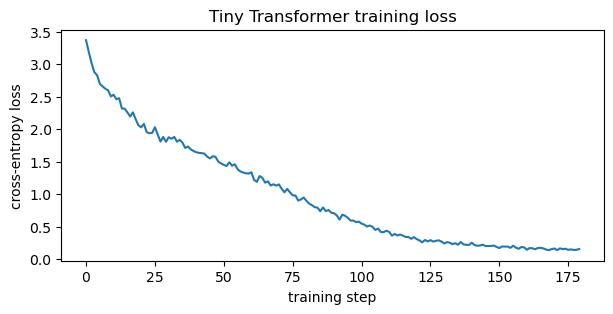

average of first 10 losses: 2.8358608961105345
average of last 10 losses : 0.15127485245466232


In [89]:
plt.figure(figsize=(7, 3))
plt.plot(loss_history)
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.title("Tiny Transformer training loss")
plt.show()

print("average of first 10 losses:", np.mean(loss_history[:10]))
print("average of last 10 losses :", np.mean(loss_history[-10:]))

#### Part IX: Autoregressive Generation (AR)

**Generation is repeated next-token sampling**

At each generation step:

1. feed the current prefix into the model;
2. take logits from the last position;
3. softmax to probabilities;
4. sample one token;
5. append it;
6. repeat.

In [90]:
@torch.no_grad()
def generate(model, start_ids, max_new_tokens, temperature=1.0):
    model.eval()
    idx = start_ids

    for _ in range(max_new_tokens):
        # Keep only as much context as the model can accept.
        idx_context = idx[:, -model.block_size:]

        # Predict logits at all current positions.
        logits, _ = model(idx_context)

        # Only the LAST position predicts the next token.
        next_logits = logits[:, -1, :]

        # Temperature changes sampling sharpness.
        next_logits = next_logits / temperature
        probs = F.softmax(next_logits, dim=-1)

        # Sample one next token ID.
        next_id = torch.multinomial(probs, num_samples=1)

        # Append and continue.
        idx = torch.cat([idx, next_id], dim=1)

    return idx

**Generate text**

The model and corpus are intentionally tiny, so don't expect magin; but then you never know!

In [95]:
prompt = "transformer "
prompt_ids = torch.tensor([encode(prompt)], dtype=torch.long)

generated_ids = generate(model, prompt_ids, max_new_tokens=160, temperature=0.8)
print(decode(generated_ids[0]))

transformer predicts the next token.
we train by reducing patrediction.
the .



 learnetion io roken er.
geatrangerlier n is trexthe next token.
we train by reducing predi


**Temperature**

Given logits $z$, temperature $\tau$ samples from

$$
\operatorname{softmax}(z/\tau).
$$

- $\tau<1$: sharper, more deterministic;
- $\tau>1$: flatter, more random.

Temperature changes sampling, not training.

In [96]:
example_logits = np.array([3.,2.,1.,0.])
for temperature in [0.3, 0.7, 1.0, 2.0]:
    p = softmax_numpy(example_logits / temperature)
    print(f"T={temperature:>3}: {np.round(p, 3)}")

T=0.3: [0.964 0.034 0.001 0.   ]
T=0.7: [0.763 0.183 0.044 0.01 ]
T=1.0: [0.644 0.237 0.087 0.032]
T=2.0: [0.455 0.276 0.167 0.102]


#### Some common misconceptions or confusions

1. **“Each head gets a fixed slice of the original embedding.”**  
   No. Each head learns projections from the full representation; efficient code often splits the projected Q/K/V tensors.

2. **“Attention weights are the values.”**  
   No. Attention weights say how strongly to combine the value vectors.

3. **“Q, K, and V are three unrelated input sequences.”**  
   In self-attention, all three come from the same $X$ through different learned projections.

4. **“Causal masking matters only during generation.”**  
   No. It is also required during autoregressive training so the model cannot cheat by seeing future targets.

5. **“A GPT-like Transformer generates a whole response simultaneously.”**  
   No. It generates one token, appends it, then predicts the next.

#### So did we learn anything at all?

A decoder-only Transformer models

$$
P(x_t\mid x_{<t}).
$$

Its parts have distinct jobs:

- **token embedding:** represent token identity as a vector;
- **position information:** represent order;
- **Q/K comparison:** decide which earlier positions matter;
- **V vectors:** carry information to be combined;
- **causal mask:** forbid future information;
- **multiple heads:** perform several learned attention projections in parallel;
- **output projection:** mix head outputs;
- **feed-forward network:** transform features at each token position;
- **residual connections:** preserve and incrementally update information;
- **LayerNorm:** stabilise representations;
- **vocabulary projection:** create next-token logits;
- **softmax + sampling:** convert logits into generated tokens.

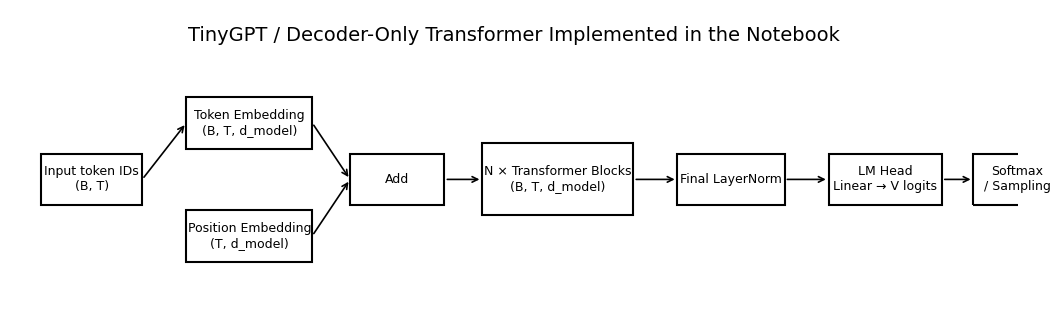

In [107]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def add_box(ax, x, y, w, h, text, fontsize=9):
    rect = Rectangle((x, y), w, h, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize)

def add_arrow(ax, x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='->',
        mutation_scale=10,
        linewidth=1.2
    )
    ax.add_patch(arrow)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis('off')

# ------------------------------------------------------------
# Boxes for the full TinyGPT pipeline
# ------------------------------------------------------------
add_box(ax, 0.5, 2.2, 1.6, 1.0, "Input token IDs\n(B, T)")
add_box(ax, 2.8, 3.3, 2.0, 1.0, "Token Embedding\n(B, T, d_model)")
add_box(ax, 2.8, 1.1, 2.0, 1.0, "Position Embedding\n(T, d_model)")
add_box(ax, 5.4, 2.2, 1.5, 1.0, "Add")
add_box(ax, 7.5, 2.0, 2.4, 1.4, "N × Transformer Blocks\n(B, T, d_model)")
add_box(ax, 10.6, 2.2, 1.7, 1.0, "Final LayerNorm")
add_box(ax, 13.0, 2.2, 1.8, 1.0, "LM Head\nLinear → V logits")
add_box(ax, 15.3, 2.2, 1.4, 1.0, "Softmax\n/ Sampling")

# ------------------------------------------------------------
# Arrows
# ------------------------------------------------------------
add_arrow(ax, 2.1, 2.7, 2.8, 3.8)   # input -> token embedding
add_arrow(ax, 4.8, 3.8, 5.4, 2.7)   # token embedding -> add
add_arrow(ax, 4.8, 1.6, 5.4, 2.7)   # position embedding -> add
add_arrow(ax, 6.9, 2.7, 7.5, 2.7)   # add -> transformer blocks
add_arrow(ax, 9.9, 2.7, 10.6, 2.7)  # blocks -> final LN
add_arrow(ax, 12.3, 2.7, 13.0, 2.7) # LN -> LM head
add_arrow(ax, 14.8, 2.7, 15.3, 2.7) # LM head -> softmax

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------
ax.text(8, 5.4, "TinyGPT / Decoder-Only Transformer Implemented in the Notebook",
        ha='center', fontsize=14)

plt.show()

#### Some fantastic references

- https://jalammar.github.io/illustrated-transformer/
- https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html (In general, the book is good https://d2l.ai)
- Bishop and Bishop, Deep Learning Book